In [2]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

plt.rcParams.update({"figure.figsize": (6, 6),
                      "axes.facecolor": "white",
                      "axes.edgecolor": "black"})

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sb.color_palette('colorblind'))
font = {'family': 'sans-serif',
         'weight': 'normal',
         'size': 14}
plt.rc('font', **font)

file_path = 'Synthetic_ICU_Dataset_CGPT.csv'
df = pd.read_csv(file_path)
df = df.drop(columns=['Patient_ID'])
df.head()

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10423 entries, 0 to 10422
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Admission Hospital         10423 non-null  object
 1   Admission Unit             10423 non-null  object
 2   Admission Date             10423 non-null  object
 3   Admission Decision Time    10423 non-null  object
 4   Admission Time             10423 non-null  object
 5   Discharge Date             10423 non-null  object
 6   Survived                   10423 non-null  int64 
 7   Diagnosis                  10423 non-null  object
 8   Length of Stay             10423 non-null  int64 
 9   Cardiovascular Support     10423 non-null  int64 
 10  Dialysis Support           10423 non-null  int64 
 11  Invasive Ventilation       10423 non-null  int64 
 12  Nutrition                  10423 non-null  int64 
 13  Age                        10423 non-null  int64 
 14  Gender

In [3]:
from datetime import datetime, timedelta

df['Admission Date'] = pd.to_datetime(df['Admission Date'], format='%Y-%m-%d')
df['Admission Decision Time'] = pd.to_datetime(df['Admission Decision Time'], format='%H:%M').dt.time
df['Admission Time'] = pd.to_datetime(df['Admission Time'], format='%H:%M').dt.time
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], format='%d/%m/%Y')

def calculate_wait_time(row):
    decision_datetime = datetime.combine(row['Admission Date'], row['Admission Decision Time'])
    admission_datetime = datetime.combine(row['Admission Date'], row['Admission Time'])

    if admission_datetime < decision_datetime:
        admission_datetime += timedelta(days=1)

    return (admission_datetime - decision_datetime).total_seconds() / 3600

df['Wait Time (hrs)'] = df.apply(calculate_wait_time, axis=1)

df['Month'] = df['Admission Date'].dt.month
season_mapping = {
    11: 'Winter', 12: 'Winter', 1: 'Winter',
    2: 'Spring', 3: 'Spring', 4: 'Spring',
    5: 'Summer', 6: 'Summer', 7: 'Summer',
    8: 'Autumn', 9: 'Autumn', 10: 'Autumn'
}

df['Season'] = df['Month'].map(season_mapping)

df.to_csv('Synthetic_ICU_Dataset_CGPT2.csv', index=False)

print(df[['Admission Date', 'Month', 'Season', 'Wait Time (hrs)']].head())

  Admission Date  Month  Season  Wait Time (hrs)
0     2022-07-19      7  Summer              2.0
1     2022-08-22      8  Autumn              2.0
2     2022-01-26      1  Winter              1.0
3     2022-02-11      2  Spring              3.0
4     2022-03-02      3  Spring              2.0


In [4]:
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)
season_tally = df['Season'].value_counts().reindex(season_order)

month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
df['Month Name'] = df['Month'].map(month_mapping)  
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)
month_tally = df['Month Name'].value_counts().reindex(month_order)

,Description,Value
0,Session id,123
1,Target,Diagnosis
2,Target type,Multiclass
3,Target mapping,"ARDS: 0, Acute kidney injury (AKI): 1, Acute liver failure: 2, Acute respiratory failure: 3, Biliary tract infections: 4, Cardiogenic shock: 5, Cerebral edema: 6, Haematological: 7, Heart failure: 8, Influenza with complication: 9, Intracranial hemorrhage: 10, Metastatic disease: 11, Multiple organ failure: 12, Pneumonia: 13, Pulmonary embolism: 14, Sepsis: 15, Septic shock: 16, Severe asthma: 17, Severe diabetic ulcers: 18, Shock: 19, Stroke: 20, Trauma: 21, Traumatic Brain Injury (TBI): 22"
4,Original data shape,"(10423, 30)"
5,Transformed data shape,"(10423, 73)"
6,Transformed train set shape,"(7296, 73)"
7,Transformed test set shape,"(3127, 73)"
8,Numeric features,20
9,Date features,2


Selected Features: Index(['Admission Hospital', 'Admission Unit', 'Admission Date',
       'Admission Decision Time', 'Admission Time', 'Discharge Date',
       'Survived', 'Length of Stay', 'Cardiovascular Support',
       'Dialysis Support', 'Invasive Ventilation', 'Nutrition', 'Age',
       'Gender', 'Unplanned_Readmission_48h', 'Unplanned_Discharge_Night',
       'High_Risk_Sepsis', 'Unit_Acquired_Infection',
       'Organ_Donation_Potential', 'ICU_Transfer', 'Delayed_Discharge_8h',
       'Delayed_Discharge_24h', 'Mortality_Risk', 'COVID_Severity',
       'COVID_Status', 'Wait Time (hrs)', 'Month', 'Season', 'Month Name'],
      dtype='object')


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.0873,0.0000,0.0873,0.0668,0.0619,0.0449,0.0456,0.1300
et,Extra Trees Classifier,0.0832,0.5289,0.0832,0.0662,0.0696,0.0411,0.0412,0.9240
lda,Linear Discriminant Analysis,0.0831,0.0000,0.0831,0.0962,0.0649,0.0408,0.0411,0.1680
rf,Random Forest Classifier,0.0762,0.5260,0.0762,0.0607,0.0634,0.0336,0.0338,0.7180
gbc,Gradient Boosting Classifier,0.0720,0.0000,0.0720,0.0600,0.0629,0.0293,0.0294,8.5480
lr,Logistic Regression,0.0705,0.0000,0.0705,0.0545,0.0572,0.0273,0.0275,4.1380
lightgbm,Light Gradient Boosting Machine,0.0670,0.5278,0.0670,0.0617,0.0633,0.0241,0.0242,2.7260
ada,Ada Boost Classifier,0.0646,0.0000,0.0646,0.0547,0.0527,0.0218,0.0221,0.4460
nb,Naive Bayes,0.0591,0.5243,0.0591,0.0866,0.0407,0.0179,0.0198,0.1780
qda,Quadratic Discriminant Analysis,0.0569,0.0000,0.0569,0.1018,0.0404,0.0155,0.0165,0.2160


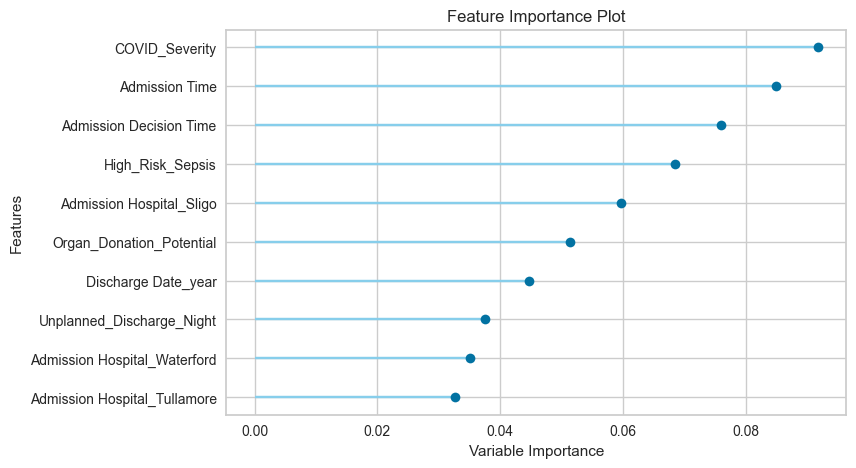

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.0966,0,0.0966,0.0843,0.0722,0.0545,0.0554


     Admission Hospital Admission Unit Admission Date Admission Decision Time  \
5945        St Vincents            ICU     2022-12-16                05:23:00   
6316               Naas            ICU     2022-04-05                10:27:00   
5700          Mullingar            ICU     2022-10-18                23:27:00   
5729             Tralee            ICU     2022-03-28                09:13:00   
2484           St James    General ICU     2022-11-30                07:05:00   

     Admission Time Discharge Date  Survived  Length of Stay  \
5945       09:23:00     2022-12-17         1               1   
6316       14:27:00     2022-04-19         1              14   
5700       00:27:00     2022-10-23         1               5   
5729       12:13:00     2022-04-04         0               7   
2484       10:05:00     2022-12-01         0               1   

      Cardiovascular Support  Dialysis Support  ...  Delayed_Discharge_24h  \
5945                       0                 0  ..

In [5]:
from pycaret.classification import *

df['Diagnosis'] = df['Diagnosis'].astype(str)

clf_setup = setup(
    data=df,
    target='Diagnosis',
    fold=5,
    session_id=123,
    verbose=True
)

selected_features = get_config('X').columns
print("Selected Features:", selected_features)

best_model = compare_models()

plot_model(best_model, plot='feature')

evaluate_model(best_model)

predictions = predict_model(best_model)
print(predictions.head())


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.0966,0,0.0966,0.0843,0.0722,0.0545,0.0554


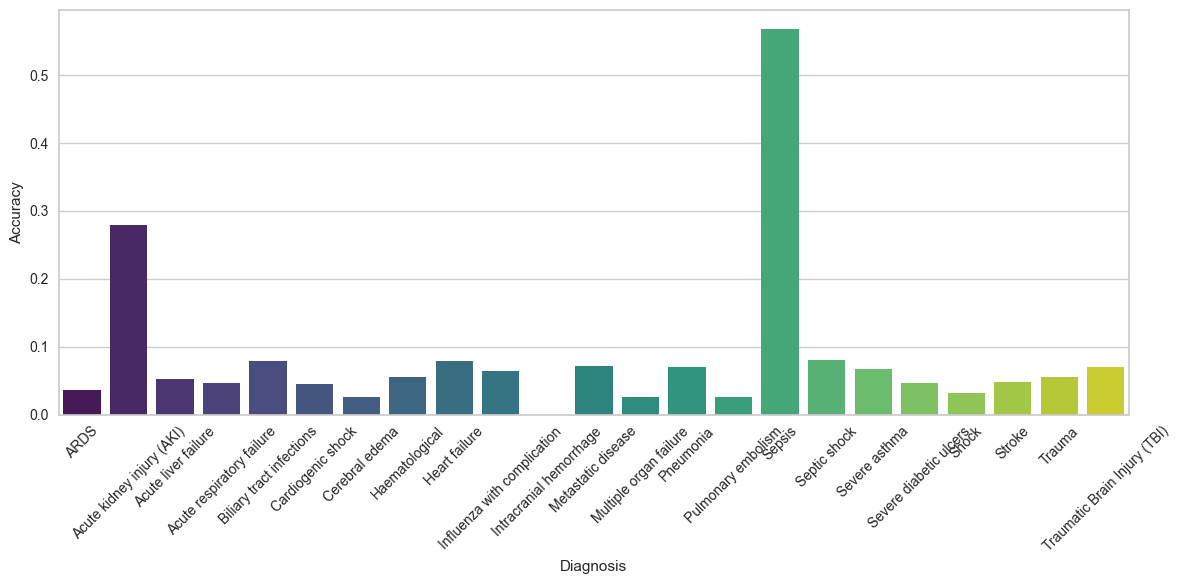

In [6]:
predictions = predict_model(best_model)

accuracy_per_illness = predictions.groupby('prediction_label').apply(
    lambda g: accuracy_score(g['Diagnosis'], g['prediction_label'])
)

plt.figure(figsize=(12, 6))
sb.barplot(x=accuracy_per_illness.index, y=accuracy_per_illness.values, palette='viridis')
plt.ylabel("Accuracy")
plt.xlabel("Diagnosis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.0747,0.5124,0.0747,0.0595,0.0639,0.0322,0.0322
1,0.0857,0.5368,0.0857,0.0664,0.0704,0.0436,0.0438
2,0.0836,0.5268,0.0836,0.0647,0.0685,0.0415,0.0416
3,0.0870,0.5372,0.0870,0.0693,0.0723,0.0450,0.0452
4,0.0850,0.5311,0.0850,0.0708,0.0727,0.0429,0.0431
Mean,0.0832,0.5289,0.0832,0.0662,0.0696,0.0411,0.0412
Std,0.0044,0.0091,0.0044,0.0040,0.0032,0.0046,0.0046


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.0877,0.5343,0.0877,0.0596,0.0629,0.0460,0.0465
1,0.0925,0.5549,0.0925,0.0616,0.0638,0.0510,0.0518
2,0.0939,0.5396,0.0939,0.0721,0.0686,0.0525,0.0532
3,0.0884,0.5494,0.0884,0.0578,0.0598,0.0465,0.0473
4,0.0912,0.5336,0.0912,0.0641,0.0619,0.0497,0.0506
Mean,0.0907,0.5424,0.0907,0.0630,0.0634,0.0491,0.0499
Std,0.0024,0.0085,0.0024,0.0050,0.0029,0.0025,0.0026


Fitting 5 folds for each of 10 candidates, totalling 50 fits


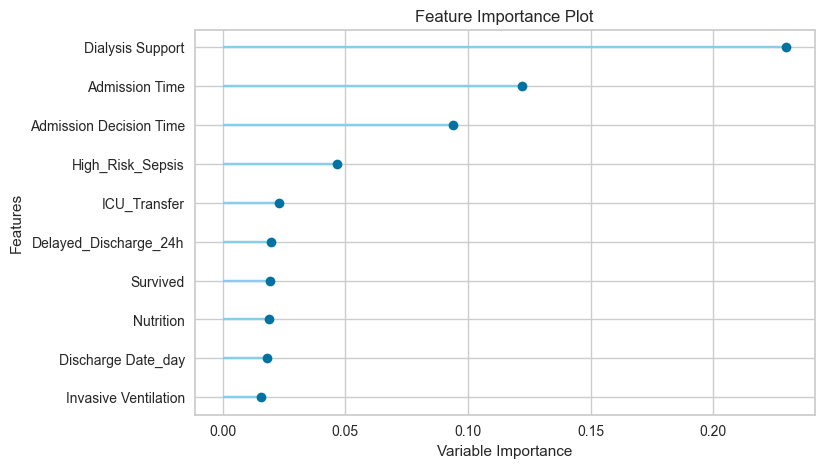

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.0963,0.5317,0.0963,0.0737,0.0707,0.0549,0.0557


Transformation Pipeline and Model Successfully Saved


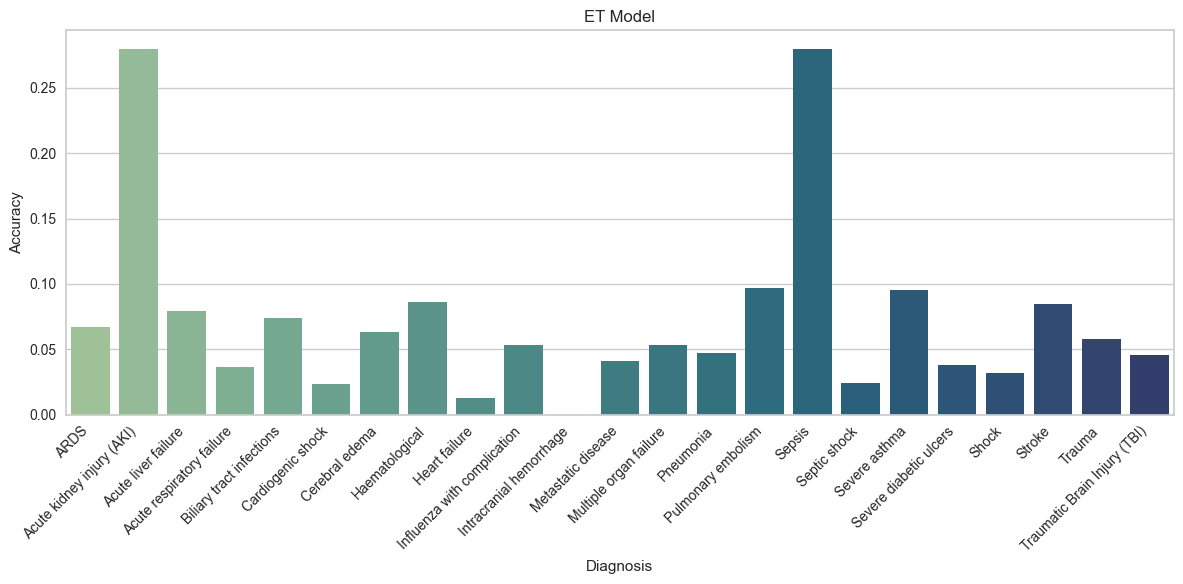

In [7]:
et_model = create_model('et')

tuned_et_model = tune_model(et_model, optimize='Accuracy')

plot_model(tuned_et_model, plot='feature')

evaluate_model(tuned_et_model)

et_predictions = predict_model(tuned_et_model)

save_model(tuned_et_model, 'diagnosis_et_model')

et_predictions['Predicted'] = et_predictions['prediction_label']

accuracy_per_illness_et = et_predictions.groupby('Predicted').apply(
    lambda g: accuracy_score(g['Diagnosis'], g['Predicted'])
)

plt.figure(figsize=(12, 6))
sb.barplot(x=accuracy_per_illness_et.index, y=accuracy_per_illness_et.values, palette='crest')
plt.title("ET Model")
plt.ylabel("Accuracy")
plt.xlabel("Diagnosis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

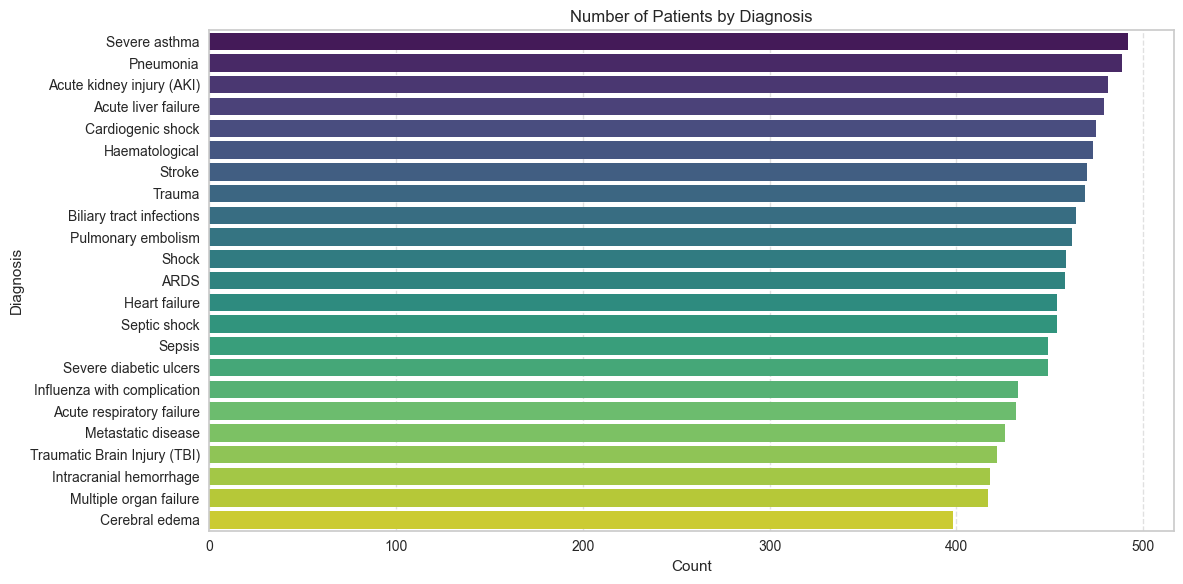

In [8]:
plt.figure(figsize=(12, 6))
sb.countplot(data=df, y='Diagnosis', order=df['Diagnosis'].value_counts().index, palette='viridis')
plt.title('Number of Patients by Diagnosis')
plt.xlabel('Count')
plt.ylabel('Diagnosis')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()